# 03 — Customer Journey Analysis

## Objetivo del notebook

El objetivo de este notebook es analizar el comportamiento de los usuarios a lo largo del **customer journey** del e-commerce, desde la visualización de un producto hasta la compra.

A partir de los datos transaccionales disponibles, se busca comprender cómo los usuarios avanzan por las diferentes etapas del proceso de compra y detectar posibles puntos de fricción u oportunidades de mejora para las acciones de CRO.

El análisis se centrará en las siguientes etapas:

**View → Cart → Remove from Cart → Purchase**

El objetivo no es únicamente describir el volumen de eventos, sino transformar estos datos en indicadores que permitan evaluar el rendimiento del funnel y generar recomendaciones accionables para el equipo de marketing.

---

## Preguntas de negocio

El análisis buscará responder principalmente:

1. ¿Cómo es el comportamiento típico de un usuario durante una sesión?

2. ¿Cuántos productos se visualizan, añaden al carrito y compran durante una sesión?

3. ¿Qué proporción de las sesiones que visualizan productos llegan a añadir productos al carrito?

4. ¿Qué proporción de las sesiones con productos en el carrito terminan en una compra?

5. ¿Cuál es la tasa de conversión global del e-commerce?

6. ¿Qué porcentaje de productos añadidos al carrito termina siendo comprado?

7. ¿Qué magnitud tiene el abandono de carrito?

8. ¿Cómo evolucionan las principales métricas del customer journey durante el periodo analizado?

9. ¿Existen determinados momentos, días o periodos en los que el comportamiento del funnel cambia significativamente?

10. ¿En qué etapas del customer journey parece existir la mayor oportunidad de mejora?

---

## KPIs principales

Se calcularán y analizarán, entre otros:

- Visitas / sesiones
- Usuarios
- Views
- Productos añadidos al carrito
- Productos eliminados del carrito
- Compras
- Tasa de conversión
- Tasa de adición al carrito
- Tasa de abandono de carrito
- Ratio de compra sobre productos añadidos al carrito
- Productos vistos por sesión
- Productos añadidos al carrito por sesión
- Productos comprados por sesión
- Ticket medio, cuando la granularidad de los datos permita calcularlo correctamente

---

## Alcance

El análisis utilizará el dataset procesado:

`data/processed/ecommerce_clean.parquet`

correspondiente al periodo:

**octubre de 2019 — febrero de 2020**

La unidad principal de análisis será la **sesión**, utilizando `user_session` como identificador de sesión y `event_type` para reconstruir el comportamiento dentro del customer journey.

También se utilizarán `user_id`, `product_id`, `price` y `event_time` cuando sean necesarios para profundizar en el análisis.

---

## Consideraciones metodológicas

El dataset registra eventos individuales, por lo que los eventos no deben interpretarse directamente como usuarios, sesiones o compras.

Por ejemplo:

- Una fila representa un evento.
- Una sesión puede contener múltiples eventos.
- Un usuario puede realizar múltiples sesiones.
- Una compra puede contener múltiples productos.

Por este motivo, las métricas se calcularán respetando la granularidad correspondiente a cada indicador.

Además, el análisis distinguirá entre:

**Métricas de volumen**  
Cantidad de eventos, sesiones, usuarios o productos.

**Métricas de comportamiento**  
Número de acciones realizadas por sesión o usuario.

**Métricas de conversión**  
Proporción de entidades que avanzan de una etapa del funnel a otra.

---

## Resultado esperado

El resultado final del notebook será una visión cuantitativa del customer journey que permita:

1. Identificar los principales puntos de fuga del funnel.
2. Detectar oportunidades de optimización CRO.
3. Establecer una línea base de KPIs del e-commerce.
4. Identificar comportamientos relevantes para análisis posteriores.
5. Generar hipótesis que puedan ser investigadas en los notebooks de clientes, productos y Machine Learning.

# **1. Carga y preparacion**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
NS_BG = "#E8E8E8"
NS_INK = "#292929"
NS_ACCENT = "#1B6B45"

# Variantes de peso/alpha para jerarquía sin usar semántica roja/verde
NS_INK_70 = "#292929B3"   # alpha 70%
NS_INK_40 = "#29292966"   # alpha 40%
NS_INK_15 = "#29292926"   # alpha 15% — gridlines, bordes suaves

plt.rcParams.update({
    # Fuentes
    "font.family": "sans-serif",
    "font.sans-serif": ["Inter", "Arial", "DejaVu Sans"],
    "font.weight": "regular",

    # Colores base
    "figure.facecolor": NS_BG,
    "axes.facecolor": NS_BG,
    "savefig.facecolor": NS_BG,
    "text.color": NS_INK,
    "axes.labelcolor": NS_INK,
    "axes.titlecolor": NS_INK,
    "xtick.color": NS_INK_70,
    "ytick.color": NS_INK_70,

    # Ejes — sin caja, jerarquía por peso
    "axes.edgecolor": NS_INK_40,
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": True,
    "axes.spines.bottom": True,

    # Grid — sutil, nunca protagonista
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.color": NS_INK_15,
    "grid.linewidth": 0.6,
    "grid.linestyle": "-",
    "axes.axisbelow": True,

    # Ciclo de color — monocromático con acento esmeralda como único highlight
    "axes.prop_cycle": plt.cycler(color=[NS_ACCENT, NS_INK, NS_INK_70, NS_INK_40]),

    # Tamaños
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    # Leyenda — sin caja, minimal
    "legend.frameon": False,
    "legend.loc": "best",

    # Export
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

In [3]:
df = pd.read_parquet('../data/processed/ecommerce_clean.parquet')

In [4]:
df.shape

(2074532, 10)

In [5]:
df.head(5)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,month
0,2019-10-01 00:01:46+00:00,view,5843665,1487580005092295511,NaN,f.o.x,9.44,462033176,a18e0999-61a1-4218-8f8f-61ec1d375361,2019-10
1,2019-10-01 00:01:55+00:00,cart,5868461,1487580013069861041,NaN,italwax,3.57,514753614,e2fecb2d-22d0-df2c-c661-15da44b3ccf1,2019-10
2,2019-10-01 00:02:50+00:00,view,5877456,1487580006300255120,NaN,jessnail,122.22,527418424,86e77869-afbc-4dff-9aa2-6b7dd8c90770,2019-10
3,2019-10-01 00:03:41+00:00,view,5649270,1487580013749338323,NaN,concept,6.19,555448072,b5f72ceb-0730-44de-a932-d16db62390df,2019-10
4,2019-10-01 00:03:44+00:00,view,18082,1487580005411062629,NaN,cnd,16.03,552006247,2d8f304b-de45-4e59-8f40-50c603843fe5,2019-10


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2074532 entries, 0 to 2074531
Data columns (total 10 columns):
 #   Column         Dtype              
---  ------         -----              
 0   event_time     datetime64[us, UTC]
 1   event_type     str                
 2   product_id     int64              
 3   category_id    int64              
 4   category_code  str                
 5   brand          str                
 6   price          float64            
 7   user_id        int64              
 8   user_session   str                
 9   month          period[M]          
dtypes: datetime64[us, UTC](1), float64(1), int64(3), period[M](1), str(4)
memory usage: 251.4 MB


## variables temporales

In [7]:
df["date"] = df["event_time"].dt.date
df["month"] = df["event_time"].dt.to_period("M")
df["day_of_week"] = df["event_time"].dt.day_name()
df["hour"] = df["event_time"].dt.hour

C:\Users\nicol\AppData\Local\Temp\ipykernel_12984\3802551167.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month"] = df["event_time"].dt.to_period("M")


In [8]:
df[["date", "month", "day_of_week", "hour"]].head(5)

,date,month,day_of_week,hour
0,2019-10-01,2019-10,Tuesday,0
1,2019-10-01,2019-10,Tuesday,0
2,2019-10-01,2019-10,Tuesday,0
3,2019-10-01,2019-10,Tuesday,0
4,2019-10-01,2019-10,Tuesday,0


In [9]:
df[["event_type", "user_id", "user_session", "product_id", "price"]].head()

,event_type,user_id,user_session,product_id,price
0,view,462033176,a18e0999-61a1-4218-8f8f-61ec1d375361,5843665,9.44
1,cart,514753614,e2fecb2d-22d0-df2c-c661-15da44b3ccf1,5868461,3.57
2,view,527418424,86e77869-afbc-4dff-9aa2-6b7dd8c90770,5877456,122.22
3,view,555448072,b5f72ceb-0730-44de-a932-d16db62390df,5649270,6.19
4,view,552006247,2d8f304b-de45-4e59-8f40-50c603843fe5,18082,16.03


In [10]:
print(f"\n{df.shape}")
print(f"\n{df.dtypes}")
print(f"\n{df['month'].value_counts().sort_index()}")


(2074532, 13)

event_time       datetime64[us, UTC]
event_type                       str
product_id                     int64
category_id                    int64
category_code                    str
brand                            str
price                        float64
user_id                        int64
user_session                     str
month                      period[M]
date                          object
day_of_week                      str
hour                           int32
dtype: object

month
2019-10    406670
2019-11    461638
2019-12    350274
2020-01    442155
2020-02    413795
Freq: M, Name: count, dtype: int64


In [11]:
df["date"] = df["event_time"].dt.normalize()

In [12]:
df["date"].dtype

datetime64[us, UTC]

# **2. Validacion de la unidad de sesion**

Convertir los eventos individuales en una visión agregada de cómo se comportan las sesiones.

In [13]:
session_months = df.groupby("user_session")["month"].nunique()

session_months.value_counts().sort_index()

month
1    444645
2      1272
3        66
4        35
5        36
Name: count, dtype: int64

In [14]:
df_sorted = df.sort_values(["user_session", "event_time"]).copy()

df_sorted["gap_min"] = (
    df_sorted.groupby("user_session")["event_time"]
    .diff()
    .dt.total_seconds() / 60
)

In [15]:
df_sorted["gap_min"].describe()

count    1.627972e+06
mean     7.147758e+01
std      2.394637e+03
min      0.000000e+00
25%      3.333333e-02
50%      2.833333e-01
75%      1.000000e+00
max      2.130185e+05
Name: gap_min, dtype: float64

In [16]:
df_sorted["gap_min"].quantile([.5, .9, .95, .99, .999])

0.500        0.283333
0.900        2.883333
0.950        5.933333
0.990       82.488167
0.999    11496.025550
Name: gap_min, dtype: float64

In [17]:
df_sorted["gap_min"].quantile(
    [0.90, 0.95, 0.97, 0.98, 0.99, 0.995, 0.999]
)

0.900        2.883333
0.950        5.933333
0.970       11.066667
0.980       20.850000
0.990       82.488167
0.995      709.050500
0.999    11496.025550
Name: gap_min, dtype: float64

In [18]:
(df_sorted["gap_min"] > 30).mean() * 100

np.float64(1.292291466219851)

In [19]:
df_session = df.sort_values(["user_id", "event_time"]).copy()

gap = (
    df_session.groupby("user_id")["event_time"]
    .diff()
    .dt.total_seconds()
    .div(60)
)

df_session["new_session"] = gap.isna() | (gap > 30)

df_session["analytical_session_id"] = (
    df_session.groupby("user_id")["new_session"]
    .cumsum()
)

In [20]:
original_sessions = df["user_session"].nunique()

analytical_sessions = (
    df_session[["user_id", "analytical_session_id"]]
    .drop_duplicates()
    .shape[0]
)

original_sessions, analytical_sessions

(446054, 332431)

In [21]:
session_comparison = {
    "original_sessions": original_sessions,
    "analytical_sessions": analytical_sessions,
    "difference": analytical_sessions - original_sessions,
    "difference_pct": (
        (analytical_sessions - original_sessions)
        / original_sessions * 100
    )
}

session_comparison

{'original_sessions': 446054,
 'analytical_sessions': 332431,
 'difference': -113623,
 'difference_pct': -25.47292480282656}

In [22]:
df.groupby("user_session")["user_id"].nunique().describe()

count    446054.000000
mean          1.000018
std           0.004735
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           3.000000
Name: user_id, dtype: float64

In [23]:
df.groupby("user_session")["user_id"].nunique().value_counts()

user_id
1    446047
2         6
3         1
Name: count, dtype: int64

In [24]:
multi_user_sessions = (
    df.groupby("user_session")["user_id"]
    .nunique()
    .loc[lambda x: x > 1]
)

multi_user_sessions

user_session
076f3767-8e09-4d95-aaea-f9a648a1d9ed    3
2f4b9bb6-d09e-49a3-9dca-2f7d6df91a56    2
54d8e7b6-2389-4db1-97b1-001f34ee72b4    2
69201792-30fe-4b72-ac04-19073c8f18ff    2
c7d92fc1-92a7-40b2-937a-112b30494637    2
dda4c891-68f5-4114-9dba-8a241b75e414    2
e8cba010-e252-45e1-806e-cffadaebedc0    2
Name: user_id, dtype: int64

Durante la exploración inicial se identificaron algunas sesiones con duraciones
extremadamente elevadas. Esto llevó a evaluar si `user_session` representaba
adecuadamente una sesión de navegación.

Se evaluó una estrategia alternativa de *sessionization* basada en 30 minutos
de inactividad. Sin embargo, esta metodología redujo el número de sesiones en
25.47%, por lo que se consideró que imponía una definición sustancialmente
diferente a la proporcionada por la fuente.

Adicionalmente, el 99.998% de las sesiones originales están asociadas a un
único usuario, por lo que se decidió conservar `user_session` como unidad de
análisis.

Las sesiones con duraciones extremas se considerarán anomalías puntuales y la
duración se analizará posteriormente mediante medidas robustas.

# **3. Radiografia de sesiones**

Aunque `user_session` permite agrupar los eventos asociados a una misma sesión,
se detectaron identificadores cuya actividad se extiende durante periodos
anormalmente largos, llegando algunos a abarcar varios meses.

Por este motivo, no se considera fiable utilizar la diferencia entre el primer
y último evento de `user_session` como medida de duración real de una sesión.

Se evaluó una estrategia alternativa de sessionization basada en 30 minutos de
inactividad, pero esta redujo el número de sesiones en 25.47%, por lo que se
descartó para mantener la granularidad proporcionada por la fuente.

En consecuencia, el análisis del customer journey utilizará `user_session`
para estudiar la presencia y secuencia de eventos, pero no para estimar la
duración de las sesiones.

In [25]:
sessions = df.groupby("user_session").agg(
    user_id=("user_id", "first"),
    events=("event_type", "size"),
    views=("event_type", lambda x: (x == "view").sum()),
    carts=("event_type", lambda x: (x == "cart").sum()),
    removes=("event_type", lambda x: (x == "remove_from_cart").sum()),
    purchases=("event_type", lambda x: (x == "purchase").sum())
).reset_index()

In [26]:
sessions.head()

,user_session,user_id,events,views,carts,removes,purchases
0,0000597b-de39-4a77-9fe5-02c8792ca14e,571211128,3,3,0,0,0
1,0000645a-8160-4a3d-91bf-154bff0a22e3,530580938,2,2,0,0,0
2,000090e1-da13-42b1-a31b-91a9ee5e6a88,609093055,1,1,0,0,0
3,0000b3cb-5422-4bf2-b8fe-5c1831d0dc1b,578886287,1,1,0,0,0
4,0000de26-bd58-42c9-9173-4763c76b398e,611657980,1,1,0,0,0


In [27]:
sessions[["events", "views", "carts", "removes", "purchases"]].describe()

,events,views,carts,removes,purchases
count,446054.000000,446054.000000,446054.000000,446054.000000,446054.000000
mean,4.649720,2.155699,1.288066,0.919972,0.285983
std,16.644624,5.290061,6.252457,8.928663,2.371865
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,0.000000,0.000000
75%,3.000000,2.000000,0.000000,0.000000,0.000000
max,2793.000000,1005.000000,778.000000,2422.000000,259.000000


In [28]:
session_reach = pd.Series({
    "view": (sessions["views"] > 0).mean() * 100,
    "cart": (sessions["carts"] > 0).mean() * 100,
    "remove_from_cart": (sessions["removes"] > 0).mean() * 100,
    "purchase": (sessions["purchases"] > 0).mean() * 100
})

session_reach

view                94.410318
cart                21.778305
remove_from_cart    10.771566
purchase             3.464155
dtype: float64

In [29]:
session_counts = pd.Series({
    "view": (sessions["views"] > 0).sum(),
    "cart": (sessions["carts"] > 0).sum(),
    "remove_from_cart": (sessions["removes"] > 0).sum(),
    "purchase": (sessions["purchases"] > 0).sum()
})

session_counts

view                421121
cart                 97143
remove_from_cart     48047
purchase             15452
dtype: int64

<Axes: title={'center': 'Session Reach'}>

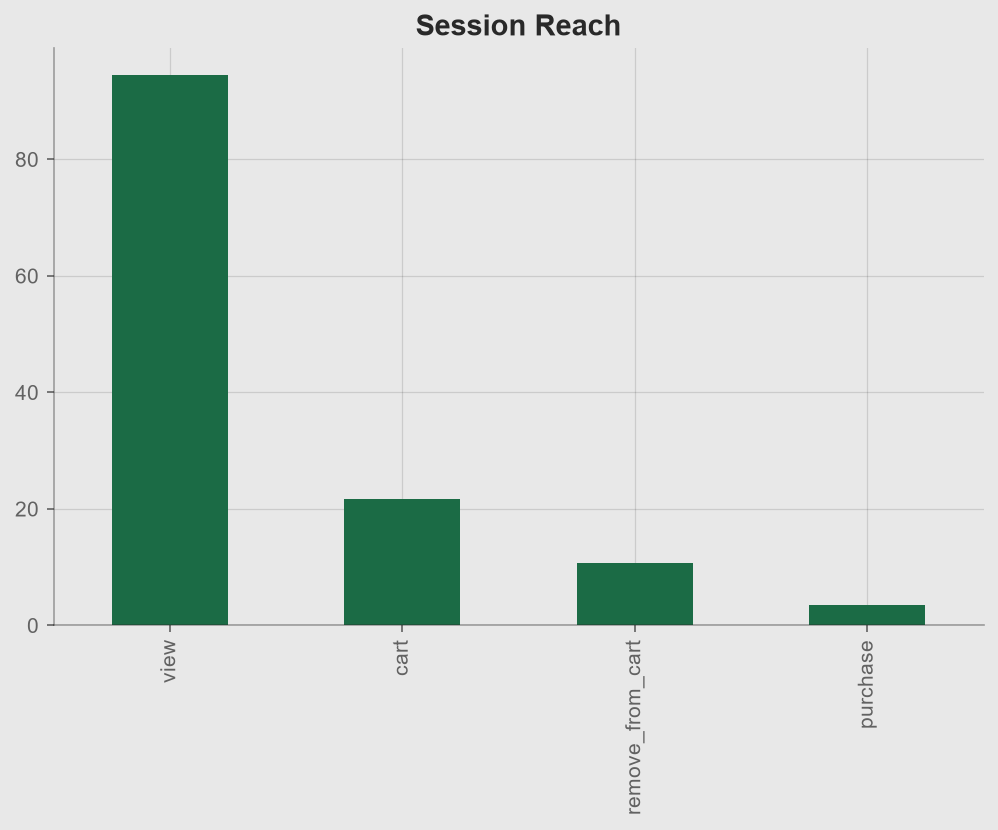

In [30]:
session_reach.plot(kind="bar", color=NS_ACCENT, title="Session Reach", figsize=(8, 5))

# **4. Customer journey**

In [31]:
session_counts

view                421121
cart                 97143
remove_from_cart     48047
purchase             15452
dtype: int64

In [32]:
session_reach

view                94.410318
cart                21.778305
remove_from_cart    10.771566
purchase             3.464155
dtype: float64

In [33]:
view_to_cart = (
    (sessions["carts"] > 0).sum() 
    / (sessions["views"] > 0).sum() 
    * 100
)

print(view_to_cart)

23.067716879471696


In [34]:
cart_to_purchase = (
    (sessions["purchases"] > 0).sum()
    / (sessions["carts"] > 0).sum()
    * 100
)

print(cart_to_purchase)

15.906447196401183


In [35]:
session_conversion = (
    (sessions["purchases"] > 0).sum()
    / len(sessions)
    * 100
)

print(session_conversion)

3.4641545642455847


In [36]:
session_conversion_views = (
    (sessions["purchases"] > 0).sum()
    / (sessions["views"] > 0).sum()
    * 100
)

print(session_conversion_views)

3.669254204848488


In [37]:
sessions[
    (sessions["purchases"] > 0) &
    (sessions["views"] == 0)
].shape[0]

3884

In [38]:
sessions[
    (sessions["purchases"] > 0) &
    (sessions["carts"] == 0)
].shape[0]

2890

In [39]:
print(f"Sesiones: {len(sessions):,}")
print(f"Sesiones con view: {(sessions['views'] > 0).sum():,}")
print(f"Sesiones con cart: {(sessions['carts'] > 0).sum():,}")
print(f"Sesiones con purchase: {(sessions['purchases'] > 0).sum():,}")

print(f"\nView → Cart: {view_to_cart:.2f}%")
print(f"Cart → Purchase: {cart_to_purchase:.2f}%")
print(f"Conversión global: {session_conversion:.2f}%")
print(f"Conversión sobre views: {session_conversion_views:.2f}%")

Sesiones: 446,054
Sesiones con view: 421,121
Sesiones con cart: 97,143
Sesiones con purchase: 15,452

View → Cart: 23.07%
Cart → Purchase: 15.91%
Conversión global: 3.46%
Conversión sobre views: 3.67%


In [40]:
session_sequences = (
    df.sort_values(["user_session", "event_time"])
      .groupby("user_session")["event_type"]
      .agg(" → ".join)
)

In [41]:
session_sequences.head(20)

user_session
0000597b-de39-4a77-9fe5-02c8792ca14e                                   view → view → view
0000645a-8160-4a3d-91bf-154bff0a22e3                                          view → view
000090e1-da13-42b1-a31b-91a9ee5e6a88                                                 view
0000b3cb-5422-4bf2-b8fe-5c1831d0dc1b                                                 view
0000de26-bd58-42c9-9173-4763c76b398e                                                 view
0000f657-db24-4b91-9a38-f62dd64864b0                                   view → view → view
00010ce9-4873-4257-bffd-824e4b706aef                                                 view
00011f29-cabd-41c3-97e3-e294813d94ec                                                 view
00013446-76b5-4bb3-89a5-0c471a69a235                            view → cart → cart → cart
000147fd-6550-4d22-8843-9960d0d3d7af    cart → cart → cart → cart → cart → cart → cart...
00018d32-afba-4db8-9d3d-562c83580579                                          view → ca

In [42]:
def compress_sequence(events):
    return " → ".join(
        event for i, event in enumerate(events)
        if i == 0 or event != events[i - 1]
    )

In [43]:
session_sequences = (
    df.sort_values(["user_session", "event_time"])
      .groupby("user_session")["event_type"]
      .agg(list)
      .apply(compress_sequence)
)

In [44]:
journey_counts = session_sequences.value_counts()

journey_counts.head(20)

event_type
view                                     337102
view → cart                               21609
cart                                      12692
view → cart → view                         6185
cart → view                                3998
remove_from_cart                           3835
view → cart → remove_from_cart             2140
cart → remove_from_cart                    2116
view → cart → view → cart                  2029
view → remove_from_cart                    1937
cart → view → cart                         1879
view → cart → view → cart → view           1547
purchase                                   1525
remove_from_cart → view                    1176
view → cart → purchase                     1123
view → remove_from_cart → view              936
cart → view → cart → view                   855
cart → purchase                             840
remove_from_cart → cart                     837
view → cart → remove_from_cart → view       725
Name: count, dtype: int64

In [45]:
journey_pct = journey_counts / len(session_sequences) * 100

journey_pct.head(20)

event_type
view                                     75.574258
view → cart                               4.844481
cart                                      2.845395
view → cart → view                        1.386603
cart → view                               0.896304
remove_from_cart                          0.859761
view → cart → remove_from_cart            0.479763
cart → remove_from_cart                   0.474382
view → cart → view → cart                 0.454878
view → remove_from_cart                   0.434252
cart → view → cart                        0.421249
view → cart → view → cart → view          0.346819
purchase                                  0.341887
remove_from_cart → view                   0.263645
view → cart → purchase                    0.251763
view → remove_from_cart → view            0.209840
cart → view → cart → view                 0.191681
cart → purchase                           0.188318
remove_from_cart → cart                   0.187645
view → cart → remove

In [46]:
journey_counts.loc["view → cart → purchase"]

np.int64(1123)

In [47]:
remove_from_cart = (
    ((df["event_type"] == "remove_from_cart")> 0).sum()
    / ((df["event_type"] == "cart") > 0).sum()
    * 100
)

print(remove_from_cart)

71.38568675604037


In [48]:
session_remove_rate = (
    (sessions["removes"] > 0).sum()
    / (sessions["carts"] > 0).sum()
    * 100
)

print(session_remove_rate)

49.46007432342011


| Métrica                                     |  Resultado | Qué mide                                                    |
| ------------------------------------------- | ---------: | ----------------------------------------------------------- |
| `remove_from_cart` / `cart` eventos         | **71.39%** | Intensidad de eventos de eliminación                        |
| Sesiones con `remove` / sesiones con `cart` | **49.46%** | % de sesiones con carrito que también registran eliminación |


In [49]:
view_only_pct = (
    (session_sequences == "view").sum()
    / len(session_sequences)
    * 100
)

view_only_pct

np.float64(75.57425782528573)

In [50]:
purchase_session_pct = (
    session_sequences.str.contains("purchase").sum()
    / len(session_sequences)
    * 100
)

purchase_session_pct

np.float64(3.4641545642455847)

In [51]:
funnel = pd.Series({
    "View": (sessions["views"] > 0).sum(),
    "Cart": (sessions["carts"] > 0).sum(),
    "Purchase": (sessions["purchases"] > 0).sum()
})

funnel_pct = funnel / len(sessions) * 100

In [52]:
import plotly.graph_objects as go

In [53]:
NS_BG = "#E8E8E8"
NS_INK = "#292929"
NS_ACCENT = "#1B6B45"

# Plotly no soporta hex+alpha (#29292966) -> usamos rgba()
NS_INK_70 = "rgba(41, 41, 41, 0.70)"
NS_INK_40 = "rgba(41, 41, 41, 0.40)"
NS_INK_15 = "rgba(41, 41, 41, 0.15)"

fig = go.Figure(go.Funnel(
    y=funnel.index,
    x=funnel.values,
    textinfo="value+percent initial",
    textposition="inside",
    textfont=dict(color=NS_BG, size=13, family="Inter, Arial, sans-serif"),
    marker=dict(
        color=[NS_ACCENT, NS_INK, NS_INK_70, NS_INK_40][:len(funnel)],
        line=dict(color=NS_BG, width=1.5),
    ),
    connector=dict(
        line=dict(color=NS_INK_40, width=1, dash="solid"),
    ),
))

fig.update_layout(
    title=dict(
        text="Customer Journey: alcance por etapa",
        font=dict(color=NS_INK, size=16, family="Inter, Arial, sans-serif", weight="bold"),
    ),
    font=dict(family="Inter, Arial, sans-serif", color=NS_INK, size=11),
    plot_bgcolor=NS_BG,
    paper_bgcolor=NS_BG,
    margin=dict(l=150, r=50, t=70, b=40),
)

fig.show()

### Señal de fricción: remove_from_cart

El **49.46% de las sesiones que registraron al menos un evento de carrito también registraron al menos un `remove_from_cart`**.

Adicionalmente, el ratio entre eventos `remove_from_cart` y eventos `cart` fue de **71.39%**.

Estas métricas no se interpretan directamente como tasa de abandono de carrito, ya que una sesión puede añadir y eliminar productos varias veces y posteriormente completar una compra. Se utilizarán como señales de fricción para un análisis posterior.

# **4. KPI's**

### **A. KPIs de trafico y usuario**

| KPI                      | Definición                                        |
| ------------------------ | ------------------------------------------------- |
| **Sesiones**             | Número de `user_session`                          |
| **Usuarios únicos**      | Número de `user_id` únicos                        |
| **Sesiones por usuario** | Sesiones / usuarios únicos                        |
| **View Rate**            | Sesiones con `view` / sesiones totales            |
| **View-only Rate**       | Sesiones únicamente con `view` / sesiones totales |

### **B. KPIs de conversion**

| KPI                 | Definición                                    |
| ------------------- | --------------------------------------------- |
| **Cart Rate**       | Sesiones con `cart` / sesiones totales        |
| **Purchase Rate**   | Sesiones con `purchase` / sesiones totales    |
| **View → Cart**     | Sesiones con `cart` / sesiones con `view`     |
| **Cart → Purchase** | Sesiones con `purchase` / sesiones con `cart` |

### **C. KPIs de friccion**

| KPI                         | Definición                                            |
| --------------------------- | ----------------------------------------------------- |
| **Cart Remove Rate**        | Sesiones con `remove_from_cart` / sesiones con `cart` |
| **Remove/Cart Event Ratio** | Eventos `remove_from_cart` / eventos `cart`           |

### **D. KPIs de facturacion**

│ Purchase Events                       │
│ Units Sold*                           │
│ Revenue*                              |
│ AOV*                                  |
│ Revenue / Session*                    |

¿Cuántos eventos purchase existen?
¿Cuántos user_session contienen compras?
¿Puede aparecer el mismo product_id varias veces como purchase dentro de una misma sesión?
¿Puede aparecer el mismo product_id varias veces como purchase para el mismo usuario?
¿El price de un purchase representa el valor de una unidad?

In [56]:
total_sessions = len(sessions)
unique_users = df["user_id"].nunique()

sessions_per_user = total_sessions / unique_users

view_rate = session_reach.view
cart_rate = session_reach.cart
purchase_rate = session_reach.purchase

view_only_rate = view_only_pct

view_to_cart = view_to_cart
cart_to_purchase = cart_to_purchase

cart_remove_rate = session_remove_rate
remove_cart_event_ratio = remove_from_cart

In [57]:
kpi_table = pd.DataFrame({
    "KPI": [
        "Sesiones",
        "Usuarios únicos",
        "Sesiones por usuario",
        "View Rate",
        "View-only Rate",
        "Cart Rate",
        "Purchase Rate",
        "View → Cart",
        "Cart → Purchase",
        "Cart Remove Rate",
        "Remove/Cart Event Ratio"
    ],
    "Valor": [
        total_sessions,
        unique_users,
        sessions_per_user,
        view_rate,
        view_only_rate,
        cart_rate,
        purchase_rate,
        view_to_cart,
        cart_to_purchase,
        cart_remove_rate,
        remove_cart_event_ratio
    ]
})

kpi_table

,KPI,Valor
0,Sesiones,446054.000000
1,Usuarios únicos,163781.000000
2,Sesiones por usuario,2.723478
3,View Rate,94.410318
4,View-only Rate,75.574258
5,Cart Rate,21.778305
6,Purchase Rate,3.464155
7,View → Cart,23.067717
8,Cart → Purchase,15.906447
9,Cart Remove Rate,49.460074


In [58]:
# KPIs de venta

df_purchases = df[df["event_type"] == "purchase"].copy()

In [61]:
print(df_purchases.shape)
print(df_purchases.info())

(127564, 13)
<class 'pandas.DataFrame'>
Index: 127564 entries, 61 to 2074473
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype              
---  ------         --------------   -----              
 0   event_time     127564 non-null  datetime64[us, UTC]
 1   event_type     127564 non-null  str                
 2   product_id     127564 non-null  int64              
 3   category_id    127564 non-null  int64              
 4   category_code  1674 non-null    str                
 5   brand          73609 non-null   str                
 6   price          127564 non-null  float64            
 7   user_id        127564 non-null  int64              
 8   user_session   127564 non-null  str                
 9   month          127564 non-null  period[M]          
 10  date           127564 non-null  datetime64[us, UTC]
 11  day_of_week    127564 non-null  str                
 12  hour           127564 non-null  int32              
dtypes: datetime64[us, UTC](2), flo

In [82]:
df_purchases.groupby(
    ["user_session", "product_id"]
).size().describe()

count    126416.000000
mean          1.009081
std           0.107599
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          10.000000
dtype: float64

In [62]:
df_purchases.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,month,date,day_of_week,hour
61,2019-10-01 00:26:49+00:00,purchase,5887011,1487580006317032337,NaN,NaN,1.59,536128518,a31f0991-645e-4472-a012-95eb2f814568,2019-10,2019-10-01 00:00:00+00:00,Tuesday,0
62,2019-10-01 00:26:49+00:00,purchase,34767,1487580006317032337,NaN,runail,1.35,536128518,a31f0991-645e-4472-a012-95eb2f814568,2019-10,2019-10-01 00:00:00+00:00,Tuesday,0
63,2019-10-01 00:26:49+00:00,purchase,34768,1487580006317032337,NaN,runail,1.35,536128518,a31f0991-645e-4472-a012-95eb2f814568,2019-10,2019-10-01 00:00:00+00:00,Tuesday,0
64,2019-10-01 00:26:49+00:00,purchase,5584,1487580009362096156,NaN,entity,1.11,536128518,a31f0991-645e-4472-a012-95eb2f814568,2019-10,2019-10-01 00:00:00+00:00,Tuesday,0
65,2019-10-01 00:26:49+00:00,purchase,5588612,1487580006317032337,NaN,irisk,3.97,536128518,a31f0991-645e-4472-a012-95eb2f814568,2019-10,2019-10-01 00:00:00+00:00,Tuesday,0


In [63]:
df_purchases["user_session"].nunique()

15452

In [64]:
df_purchases["product_id"].nunique()

23477

In [67]:
# Total unidades vendidas
units_sold = len(df_purchases)
units_sold

127564

In [70]:
# Total revenue
revenue = df_purchases["price"].sum()
print(revenue)

621549.6000000001


In [71]:
# Compradores
unique_buyers = df_purchases["user_id"].nunique()
unique_buyers

11040

In [72]:
# sesiones de compra
purchase_sessions = df_purchases["user_session"].nunique()
purchase_sessions

15452

In [74]:
# revenue por comprador 
revenue_per_buyer = revenue / unique_buyers
print(revenue_per_buyer)

56.29978260869566


In [76]:
# Revenue por sesion con compra
revenue_per_purchase_session = revenue / purchase_sessions
print(revenue_per_purchase_session)

40.224540512555016


In [78]:
# Revenue por mes
revenue_by_month = (
    df_purchases
    .groupby("month")["price"]
    .sum()
)
print(revenue_by_month)

month
2019-10    116519.04
2019-11    146491.24
2019-12    102034.20
2020-01    135174.45
2020-02    121330.67
Freq: M, Name: price, dtype: float64


In [80]:
# Unidades vendidas por mes
units_by_month = (
    df_purchases
    .groupby("month")
    .size()
)
units_by_month

month
2019-10    23930
2019-11    30723
2019-12    20540
2020-01    27455
2020-02    24916
Freq: M, dtype: int64

In [83]:
# estadisticas sobre la columna de precio

df_purchases["price"].describe()

count    127564.000000
mean          4.872453
std           8.670436
min           0.050000
25%           1.590000
50%           3.000000
75%           5.320000
max         327.780000
Name: price, dtype: float64

### Precio de compra y AOV

Se analizó la distribución de `price` para los eventos `purchase` con el objetivo
de obtener una referencia del valor económico de las compras.

El dataset no contiene un identificador explícito de orden (`order_id`), por lo
que no es posible calcular un AOV tradicional de forma directa.

Por este motivo, se utilizará como métrica descriptiva el **Average Revenue per
Purchase Event**, calculado como el revenue total dividido entre el número de
eventos `purchase`.

Esta métrica representa el valor medio asociado a un evento de compra y no debe
interpretarse como ticket medio por orden.

### **KPIs**

#### **KPIs de trafico, conversion, friccion**

| KPI                     |   Valor |
| ----------------------- | ------: |
| Sesiones                | 446,054 |
| Usuarios únicos         | 163,781 |
| Sesiones por usuario    |    2.72 |
| View Rate               |  94.41% |
| View-only Rate          |  75.57% |
| Cart Rate               |  21.78% |
| Purchase Rate           |   3.46% |
| View → Cart             |  23.07% |
| Cart → Purchase         |  15.91% |
| Cart Remove Rate        |  49.46% |
| Remove/Cart Event Ratio |  71.39% |


#### **KPIs de facturacion**

| KPI                              |      Valor |
| -------------------------------- | ---------: |
| Purchase Events                  |    127,564 |
| Compradores                      |     11,040 |
| Sesiones con compra              |     15,452 |
| Revenue                          | 621,549.60 |
| Revenue por comprador            |      56.30 |
| Valor medio por evento de compra |       4.87 |
| Mediana por evento de compra     |       3.00 |



# **5. Analisis temporal**

# **6. Analisis de abandono**

# **7. Comportamiento por sesion**

# **8. Segmentacion**

# **9. Insights CRO**